# 042 可靠神经网络阶段项目

清空内核，从头执行。我们比较按行与按实体的目标，保留强基线获胜和区域退化。本Notebook实际重做12次神经拟合及所有最终数值。

In [1]:
from pathlib import Path
import hashlib, json, sys
BASE=Path.cwd()
if not (BASE/'experiment.py').is_file():
    BASE=BASE/'units'/'042'
BASE=BASE.resolve()
EXPECTED={'experiment.py': '991b51bfd680c3de0a6e9f4fc6b78846996e775b7c39d748577a244e1e5d23c2', 'test_experiment.py': 'ba4d17e5bf28d809c573e11383100135b62b79ce475dd5eabe3f8c7a31c35208', 'make_figures.py': 'bf6127a7189da9443d8ebfd949ddc53f95c35b8aa7b3a4045148b8f6ec3776f8', 'generate_data.py': '9a7c567516611fd66bb74c515cf09ae40946c37dfa731b80676391cc325cd0a1', 'environment.yml': '40bef5b8ba65319ed6dc5336e055374d31f3f65bd17c0393fd8eb4c3e9b2237d', 'data/README.md': '5b203d5a7ac4bd4b092ea49bcd4aef73408bf465ee5e606fb4077427ff24bcc0', 'data/fixture-hashes.json': 'e3153af9505b63d23a2bdc35916735cca477b4d8cfb43f8a4926650dfaa3b092', 'data/protocol.json': '32062805bbbec66cc2d1dde82a242fb9abab70eaa7b2d6e3062bf51efc8a5420', 'data/test.csv': '14794b91105620fbd6519df4dbb4477e5c39e68e1a39d58fdc8316741bf93292', 'data/train.csv': '6528f8a4eaff59dd33b77292cfe3ce2a0039e90b86d49871990e6556684943e9', 'data/validation.csv': '36ef9b9efdb692ffe6e25df46029cd116c5eb0ce7f33f0e1d830706b6ec6c6eb', 'outputs/final_evaluation.json': '18f0f26550b456ec29c7fa68a52e29ec602f4bb3c8f950160b1177db2b98617f', 'outputs/hand_chain.json': '745cdda30f60114ea2c395fecb5c5441f444336f7a28b36168d28dacfae038a4', 'outputs/identity_leakage.json': '1cfd06997dc74d6fc6116067a55616b4fa8c09c1da3f871053e9a6b1f33f87ff', 'outputs/results.json': '0c26b41bdea78fcaf002d770ce172ae99a10ec24d94554c07293614dd11f449b', 'outputs/training_curves.csv': '89b88dcce9a9cced94a044e1a9924deeabf7d073ce1b28c730e266ed394b5450', 'outputs/training_traces.json.gz': 'd2c9e1439d065d41cb2a56df58daaad7d03365b68cef4262b00929bf653babd1', 'figures/01_audit_chain.png': '8a991df209a2574577a093d31e4fafc11bc363950d91c4e832d56f303155e41d', 'figures/02_two_estimands.png': 'f49493955b81723a90fbc399e6411a21d7b20a8fd8e9a25228f8646bc04e0e1f', 'figures/03_entity_data.png': '5e2b3af9f7754b1dc46051370eca5c11f31b35f7dd77c5c1a23e5cdbd5e787a0', 'figures/04_hand_graph.png': '11022c33112a38183a9cc4350dfbc6504628b6cb941102094f0147fc3a4e14a9', 'figures/05_gradient_ledger.png': '96c3ee7753d191e18b23ceab69d886b250b49ef373e2030003babfde52d212cd', 'figures/06_hand_updates.png': '57f6a66cf6d7d5d880a013c8816a597542cd8354a8cdfbea2e3c0cc2f446c7ae', 'figures/07_budget_match.png': '6a6195aad199ede14e01f18487bf73fe004706c373c6ca46368d459e43348975', 'figures/08_training_curves.png': 'af721b7db5c25d8442d8acce62194e5321b5f58de26f60fad2d74bdf3f937545', 'figures/09_validation_selection.png': '0dc9fc217c8aff25afca7b26600bfbdd90336f7c5ea235245b40c6ba3527384b', 'figures/10_strong_baseline.png': 'ef37a1ac04cfb72e70d8a27070afef832806033a1b0f944db90a42efcc058689', 'figures/11_test_risks.png': 'a844178445772c431aa1889e5b8f7444e193ea754f8aa11fd4abe6cc89970cee', 'figures/12_entity_bootstrap.png': 'd6e26b1b443d2a98ee1737aefe26af0e4fd8c5ba2c48228f6e34327bfa4f6170', 'figures/13_retained_errors.png': '89e5efbe71239d483d189a7932f6bfaed4d071eac1c510dd741b5b1fbdfac0e0', 'figures/14_identity_leakage.png': '52fd1955d81f7a73af5ef18cf3678c52850af948247634890f2435a569fc1627', 'figures/15_evidence_scope.png': 'd711bfacbadefe1a6f42a88a3c5f3297aaf7da468aa60f7eda5957f3b262de5f'}
for relative, expected in EXPECTED.items():
    target=BASE/relative
    if not target.is_file() or hashlib.sha256(target.read_bytes()).hexdigest()!=expected:
        raise RuntimeError('缺失或改动的参考文件：'+relative)
sys.dont_write_bytecode=True
sys.path.insert(0,str(BASE))
import experiment as e
import numpy as np
import torch, gzip, tempfile, unittest
from IPython.display import display, Image
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
print('checked reference files:',len(EXPECTED))
print({'python':sys.version.split()[0],'numpy':np.__version__,'torch':torch.__version__,'device':'cpu'})

checked reference files: 32
{'python': '3.12.14', 'numpy': '2.3.5', 'torch': '2.7.1+cpu', 'device': 'cpu'}


## 1 先定义目标与独立单位
完整性哈希不参与选参。这里仅解析训练和验证；所有测试决定都在主流程最后。

Does equal-entity training weighting improve equal-new-entity prediction risk compared with equal-row training weighting in this fixed synthetic repeated-measurement problem?
uniformly sample a new entity, then uniformly sample one of its measurement rows
train rows: 224 entities: 40 sum weights: 1.0
validation rows: 190 entities: 32 sum weights: 1.0


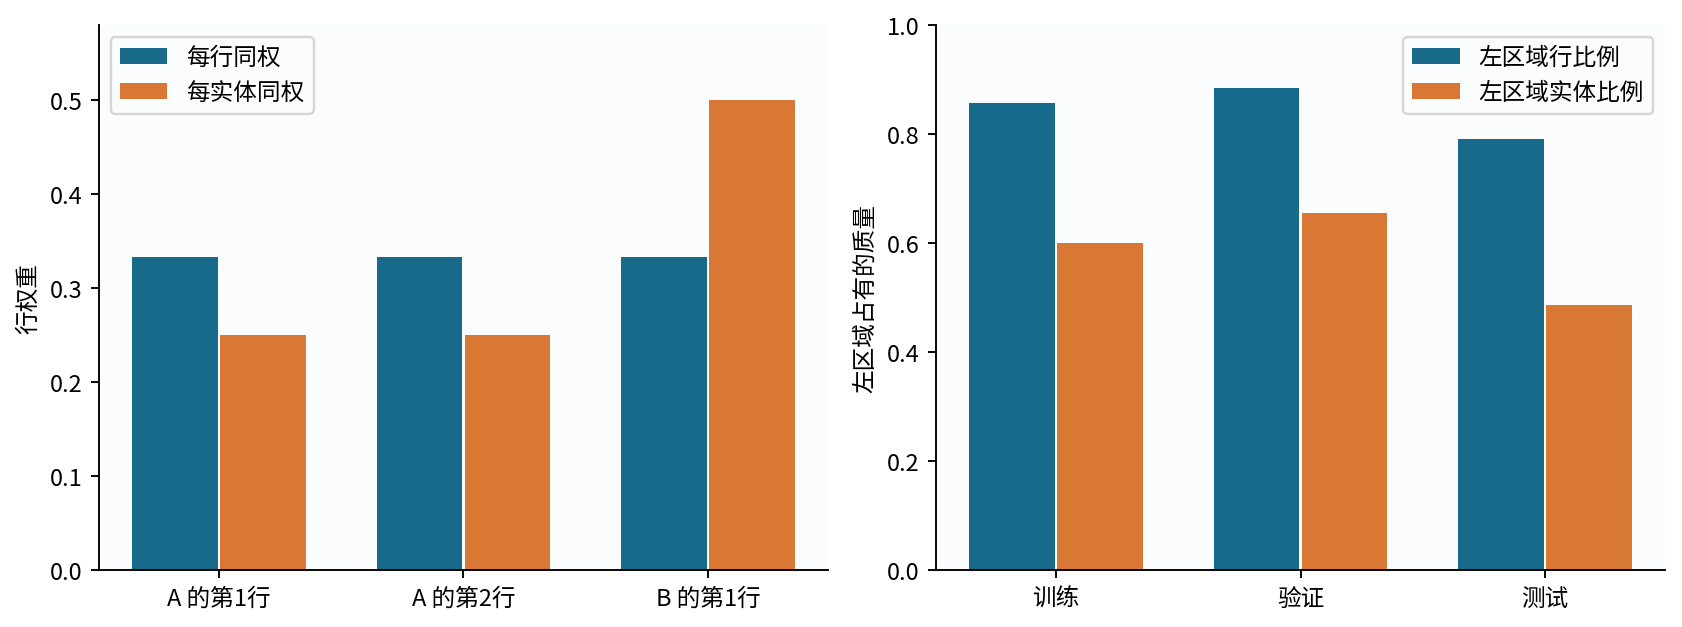

In [2]:
plan=e.verify_inputs();train=e.load_split('train');validation=e.load_split('validation')
print(plan['question']);print(plan['target'])
for name,data in [('train',train),('validation',validation)]:
    q=e.weights(data['groups'],'entity')
    print(name,'rows:',len(data['y']),'entities:',len(set(data['groups'])),'sum weights:',q.sum())
if set(train['groups'])&set(validation['groups']):raise RuntimeError('实体重叠')
display(Image(filename=str(BASE/'figures/02_two_estimands.png')))

## 2 三行七参数两轮精确链
输出Fraction账本，显示每条样本路径、正则路径、所有同步更新和下一次前向。

In [3]:
hand=e.hand_trace()
for step,s in enumerate(hand['steps']):
    print('round',step,'theta:',[float(v) for v in s['theta']])
    for row in s['rows']:
        print('x/y/q:',*[float(row[k]) for k in ('x','y','weight')])
        print('z/h:',[float(v) for v in row['z']],[float(v) for v in row['h']])
        print('prediction/residual/upstream:',*[float(row[k]) for k in ('prediction','residual','weighted_upstream')])
        print('all seven contributions:',[float(v) for v in row['contribution']])
    for key in ('data_loss','regularizer','objective'):print(key,s[key])
    for key in ('data_gradient','regularizer_gradient','gradient','after'):print(key,[float(v) for v in s[key]])
print('third predictions:',[float(r['prediction']) for r in hand['third_forward']])
print('third objective:',float(hand['third_objective']))

round 0 theta: [0.5, -0.5, 1.0, 1.0, 1.0, -0.5, 0.0]
x/y/q: -1.0 0.0 0.25
z/h: [0.5, 1.5] [0.5, 1.5]
prediction/residual/upstream: -0.25 -0.25 -0.0625
all seven contributions: [0.0625, -0.03125, -0.0625, 0.03125, -0.03125, -0.09375, -0.0625]
x/y/q: 0.0 1.0 0.25
z/h: [1.0, 1.0] [1.0, 1.0]
prediction/residual/upstream: 0.5 -0.5 -0.125
all seven contributions: [0.0, 0.0, -0.125, 0.0625, -0.125, -0.125, -0.125]
x/y/q: 1.0 0.0 0.5
z/h: [1.5, 0.5] [1.5, 0.5]
prediction/residual/upstream: 1.25 1.25 0.625
all seven contributions: [0.625, -0.3125, 0.625, -0.3125, 0.9375, 0.3125, 0.625]
data_loss 55/128
regularizer 7/80
objective 331/640
data_gradient [0.6875, -0.34375, 0.4375, -0.21875, 0.78125, 0.09375, 0.4375]
regularizer_gradient [0.05, -0.05, 0.0, 0.0, 0.1, -0.05, 0.0]
gradient [0.7375, -0.39375, 0.4375, -0.21875, 0.88125, 0.04375, 0.4375]
after [0.42625, -0.460625, 0.95625, 1.021875, 0.911875, -0.504375, -0.04375]
round 1 theta: [0.42625, -0.460625, 0.95625, 1.021875, 0.911875, -0.504375, 

## 3 单条路径的autograd核对
权重q已经归一化，不能再除以样本数。

In [4]:
coords=0;largest=0.
for s in hand['steps']:
    for row in s['rows']:
        theta=torch.tensor([float(v) for v in s['theta']],dtype=torch.float64,requires_grad=True)
        h=torch.relu(theta[:2]*float(row['x'])+theta[2:4])
        p=h@theta[4:6]+theta[-1]
        contribution=float(row['weight'])*(p-float(row['y'])).square()/2
        g=torch.autograd.grad(contribution,theta)[0].numpy()
        reference=np.array([float(v) for v in row['contribution']])
        np.testing.assert_allclose(g,reference,atol=2e-15,rtol=0)
        largest=max(largest,float(np.max(np.abs(g-reference))));coords+=len(g)
print('sample-parameter contributions:',coords,'max error:',largest)

sample-parameter contributions: 42 max error: 5.551115123125783e-17


## 4 真正重做全部12次神经拟合
在临时目录计算完整六文件，再与固定参考逐字节比较。不用旧结果代替训练。

In [5]:
with tempfile.TemporaryDirectory(prefix='dl042-rerun-') as tmp:
    result=e.run(Path(tmp))
    same={name:hashlib.sha256((Path(tmp)/name).read_bytes()).hexdigest()==hashlib.sha256((BASE/'outputs'/name).read_bytes()).hexdigest() for name in e.OUTPUT_NAMES}
    print(same)
    if not all(same.values()):raise RuntimeError('数值输出未全部复现')
print(result['counts'])
for event in result['access_ledger']:print(event)

{'results.json': True, 'hand_chain.json': True, 'final_evaluation.json': True, 'identity_leakage.json': True, 'training_curves.csv': True, 'training_traces.json.gz': True}
{'neural_fits': 12, 'updates': 4200, 'parameter_states': 4212, 'parameter_coordinates': 105300, 'neural_parameters_per_model': 25, 'row_presentations_per_mode': 470400, 'polynomial_fits': 4, 'linear_fits': 1, 'constant_fits': 1}
checked fixture hashes without using test labels for decisions
parsed train and validation
fit one training-only entity-weighted normalization for both MLP modes
froze both MLP rates and polynomial regularization using validation only
parsed test only after all choices; final fixed predictions and entity-paired interval


## 5 无损轨迹与第一次同步更新
参数状态0是初始点，状态350是350次更新后。每次运行有351个状态。

In [6]:
raw=gzip.decompress((BASE/'outputs/training_traces.json.gz').read_bytes())
if len(raw)!=result['trace_storage']['raw_bytes'] or hashlib.sha256(raw).hexdigest()!=result['trace_storage']['raw_sha256']:
    raise RuntimeError('完整轨迹摘要不一致')
runs=json.loads(raw)['runs'];r=runs[0]
p=np.array(r['parameters'][0]);x=e.transform(train['x'],r['normalization']);q=e.weights(train['groups'],r['mode'])
g=e.numpy_gradient(p,x,train['y'],q,r['l2'],r['width'])
np.testing.assert_allclose(p-r['lr']*g,r['parameters'][1],atol=2e-15,rtol=1e-13)
print('runs/states:',len(runs),sum(len(z['parameters']) for z in runs))
print('first gradient:',g)

runs/states: 12 4212
first gradient: [ 2.24659217e-02 -1.88435863e-04 -9.46881166e-03  2.66968567e-02
 -4.89103584e-04  3.37578734e-02 -3.02007958e-02  3.71842496e-02
 -5.71350828e-02  1.27877419e-01  6.61618754e-03  8.53446171e-02
 -1.35258756e-02 -2.19011711e-02  3.71351923e-02 -8.94185581e-02
 -2.68013603e-03 -7.50824224e-02 -1.56562511e-01 -1.26491252e-01
 -2.23810874e-01 -2.15069541e-01 -1.78859379e-01  2.63298000e-01
 -1.49979149e-01]


## 6 验证预算与预处理一致
匹配神经训练预算，不把经典求解器的一次拟合当成神经的一次更新。

six paired runs start identically; same normalization and row presentations


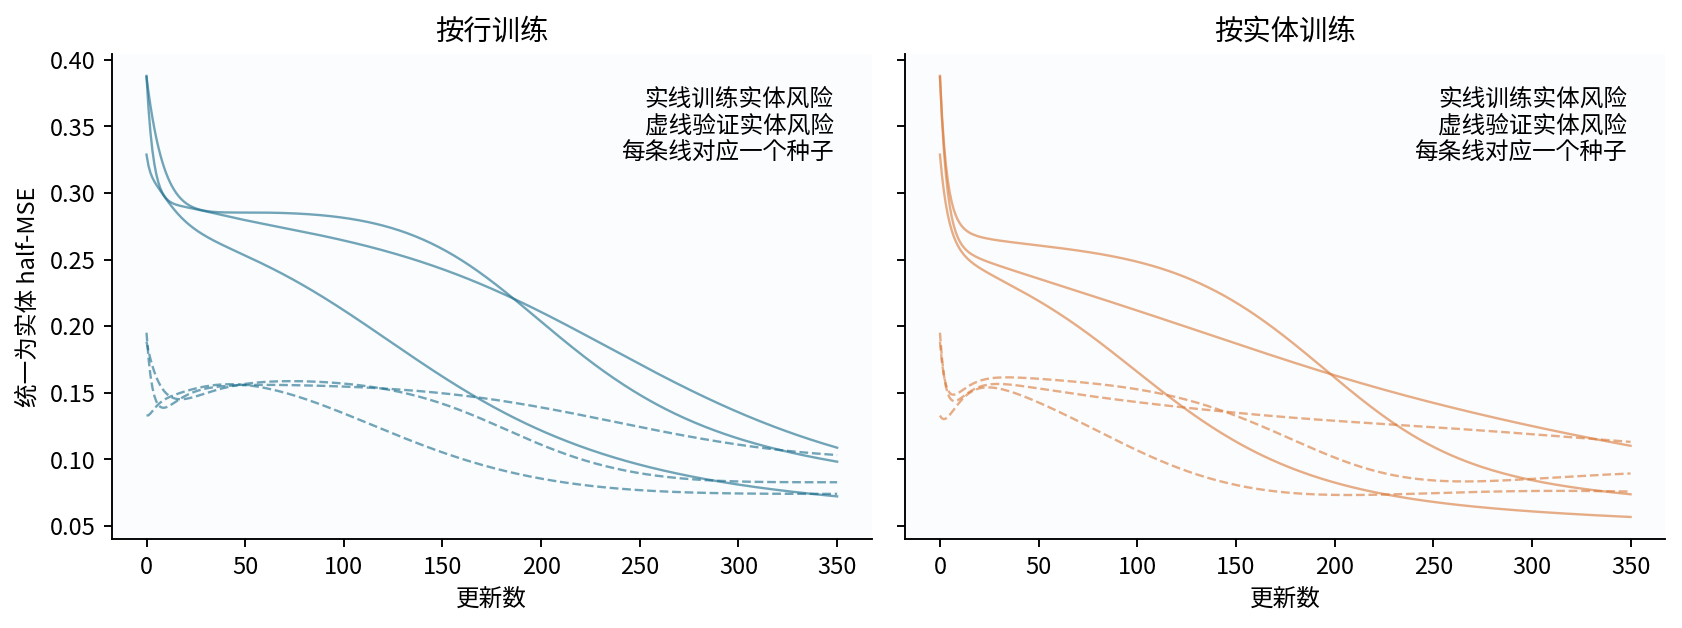

In [7]:
for lr in plan['learning_rates']:
    for seed in plan['seeds']:
        a=next(z for z in runs if z['mode']=='row' and z['lr']==lr and z['seed']==seed)
        b=next(z for z in runs if z['mode']=='entity' and z['lr']==lr and z['seed']==seed)
        if a['parameters'][0]!=b['parameters'][0] or a['normalization']!=b['normalization'] or a['row_presentations']!=b['row_presentations']:
            raise RuntimeError('配对或预算不一致')
print('six paired runs start identically; same normalization and row presentations')
display(Image(filename=str(BASE/'figures/08_training_curves.png')))

## 7 保留所有验证候选与强基线
验证排序并非都支持实体加权；不能删掉这些分数。

{'mode': 'row', 'lr': 0.03, 'mean_validation_entity_half_mse': 0.14729935230856417, 'seed_losses': [0.15436451860600248, 0.15617495966067138, 0.13135857865901865]}
{'mode': 'row', 'lr': 0.1, 'mean_validation_entity_half_mse': 0.08682503985051059, 'seed_losses': [0.10335186313217917, 0.08291836001568109, 0.07420489640367149]}
{'mode': 'entity', 'lr': 0.03, 'mean_validation_entity_half_mse': 0.1322282836519191, 'seed_losses': [0.14212261991973144, 0.1512623167392512, 0.1032999142967747]}
{'mode': 'entity', 'lr': 0.1, 'mean_validation_entity_half_mse': 0.09287519322970343, 'seed_losses': [0.11318937354153497, 0.08948552934295737, 0.07595067680461798]}
chosen rates: {'row': 0.1, 'entity': 0.1}
polynomial lambda: 0.0001 validation entity risk: 0.050786905955902
polynomial lambda: 0.001 validation entity risk: 0.050481458791842494
polynomial lambda: 0.01 validation entity risk: 0.04825949692021899
polynomial lambda: 0.1 validation entity risk: 0.04998950874828852
chosen polynomial index: 2


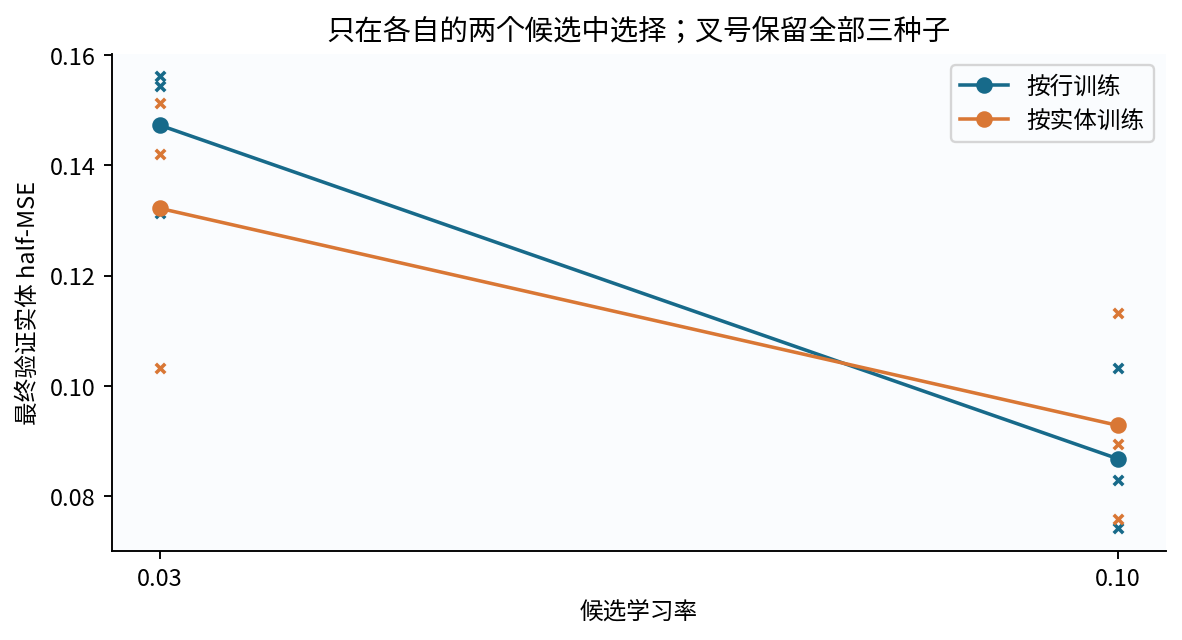

In [8]:
for s in result['network_scores']:print(s)
print('chosen rates:',result['selected_learning_rates'])
for b in result['baselines']['polynomial_candidates']:
    print('polynomial lambda:',b['l2'],'validation entity risk:',b['validation_entity_half_mse'])
print('chosen polynomial index:',result['baselines']['selected_polynomial_index'])
display(Image(filename=str(BASE/'figures/09_validation_selection.png')))

## 8 固定测试结果
先实体内平均再跨实体平均。左区域有所退化，强多项式基线更好。

{'model': 'row', 'region': 'all', 'entities': 160, 'rows': 788, 'entity_half_mse': 0.1405370015553223, 'entity_rmse': 0.5301641284646148, 'row_half_mse': 0.08376296162534043}
{'model': 'row', 'region': 'left', 'entities': 78, 'rows': 624, 'entity_half_mse': 0.04494310526295968, 'entity_rmse': 0.2998102908939574, 'row_half_mse': 0.044943105262959686}
{'model': 'row', 'region': 'right', 'entities': 82, 'rows': 164, 'entity_half_mse': 0.23146778095537457, 'entity_rmse': 0.6803936815629237, 'row_half_mse': 0.2314677809553746}
{'model': 'entity', 'region': 'all', 'entities': 160, 'rows': 788, 'entity_half_mse': 0.09016470046674857, 'entity_rmse': 0.42465209399400955, 'row_half_mse': 0.06633988570633753}
{'model': 'entity', 'region': 'left', 'entities': 78, 'rows': 624, 'entity_half_mse': 0.05004941407528726, 'entity_rmse': 0.31638398845481186, 'row_half_mse': 0.05004941407528727}
{'model': 'entity', 'region': 'right', 'entities': 82, 'rows': 164, 'entity_half_mse': 0.12832314361960198, 'ent

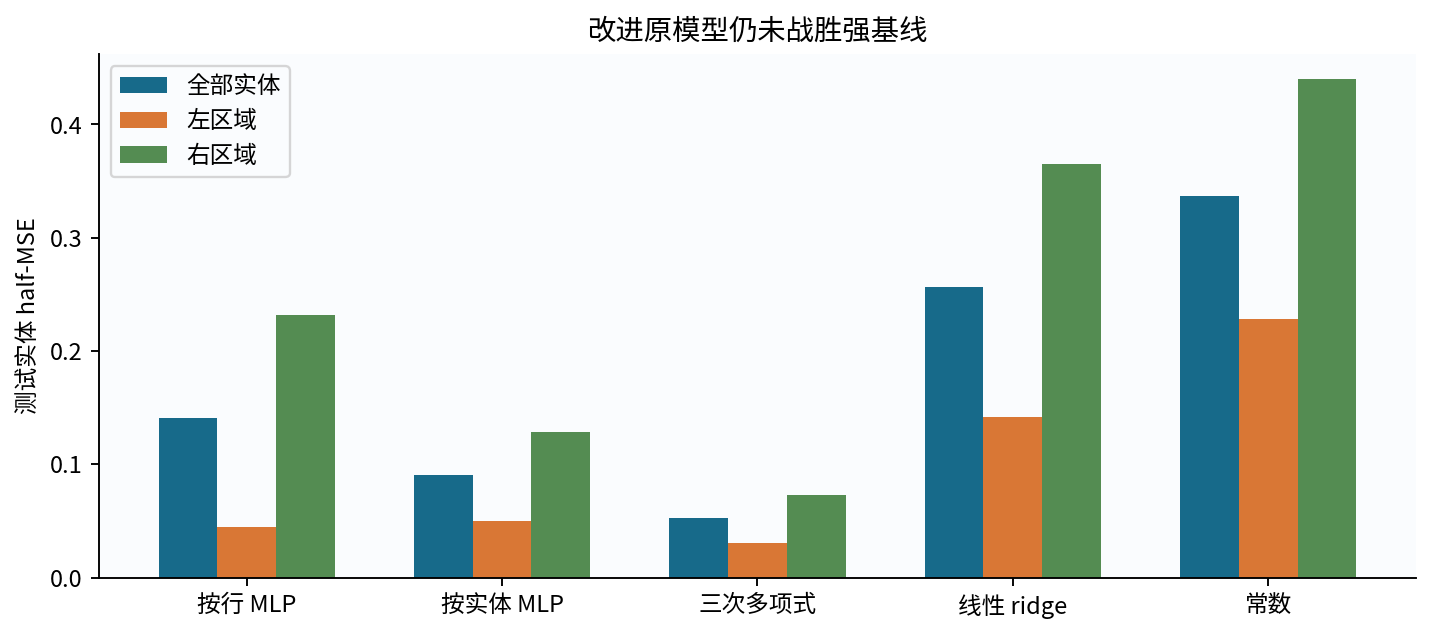

In [9]:
final=json.loads((BASE/'outputs/final_evaluation.json').read_text())
for metric in final['metrics']:print(metric)
for mode in ('row','entity'):
    mean_seed=np.mean([s['entity_half_mse'] for s in final['seed_metrics'] if s['mode']==mode])
    ensemble=next(m['entity_half_mse'] for m in final['metrics'] if m['model']==mode and m['region']=='all')
    print(mode,'mean individual loss:',mean_seed,'ensemble loss:',ensemble)
display(Image(filename=str(BASE/'figures/11_test_risks.png')))

## 9 整实体配对bootstrap
固定训练和选择。抽到同一实体多次时必须保留其多次贡献。

difference: -0.050372301088573754 interval: [-0.07849287947835318, -0.02509652802730145]
entities worse: 78 entities better: 82
fixed training/selection/fitted models; no retraining, no retuning


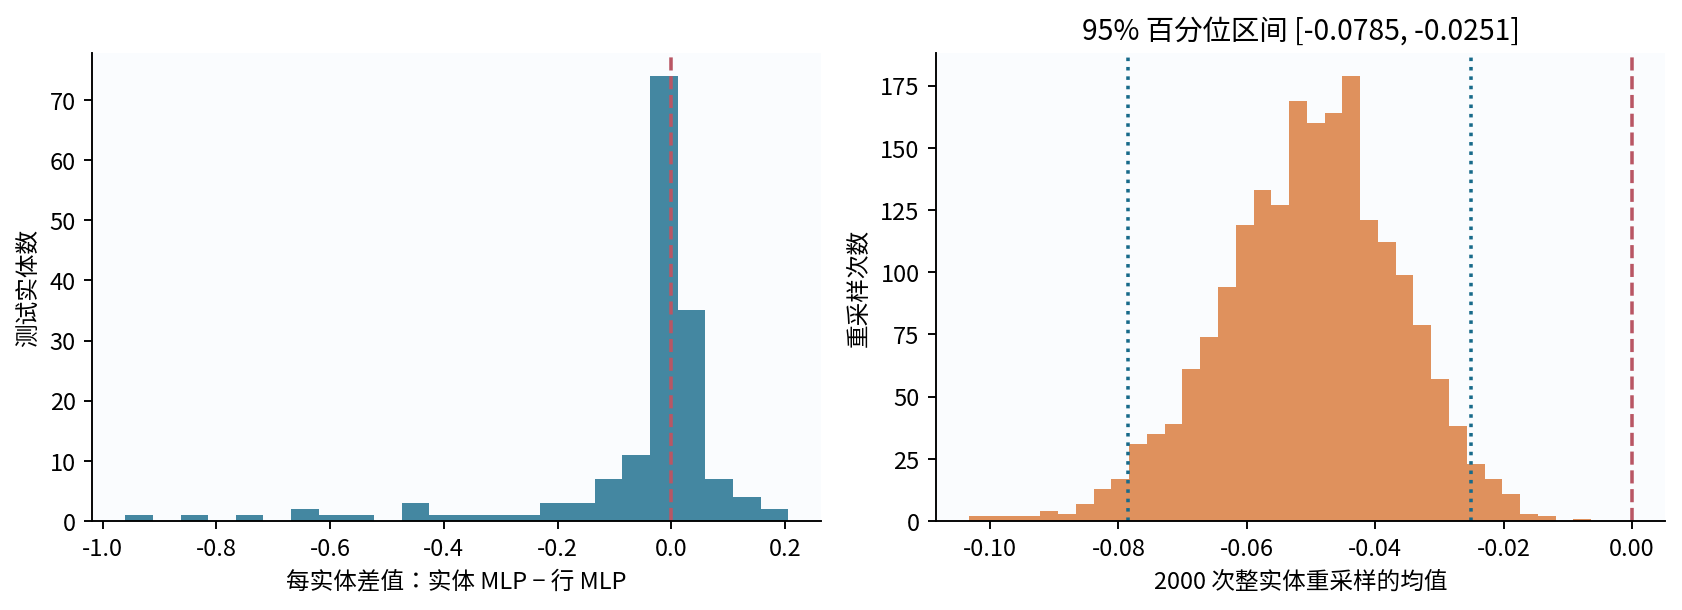

In [10]:
pb=final['primary_paired_bootstrap'];d=np.array(final['per_entity_half_mse']['entity'])-np.array(final['per_entity_half_mse']['row'])
redo=e.paired_bootstrap(d,2000,4291)
np.testing.assert_array_equal(redo['bootstrap_means'],pb['bootstrap_means'])
print('difference:',pb['mean'],'interval:',pb['percentile_95'])
print('entities worse:',int((d>0).sum()),'entities better:',int((d<0).sum()))
print(pb['conditional_on'])
display(Image(filename=str(BASE/'figures/12_entity_bootstrap.png')))

## 10 身份记忆的独立失败例
此处两个方案的部署任务和测试实体不同，不是主MLP的配对效果。

seen_empirical_half_mse 0.006827960675684563
unseen_empirical_half_mse 0.42647490452117937
seen_theoretical_half_mse 0.006666666666666666
unseen_theoretical_half_mse 0.5133541666666667
Different prediction tasks and different test entity sets; descriptive leakage mechanism, not a paired MLP comparison or proof about all splits.


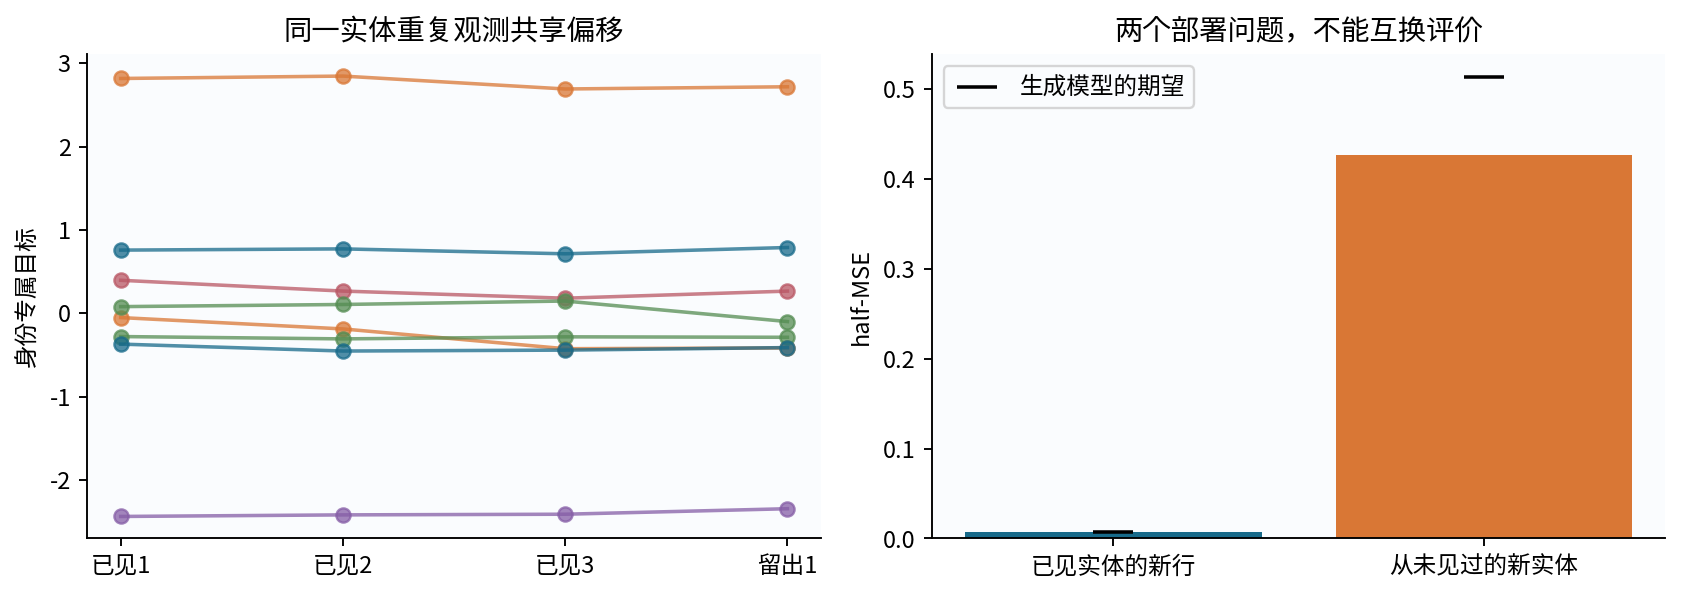

In [11]:
leak=e.identity_leakage()
for key in ('seen_empirical_half_mse','unseen_empirical_half_mse','seen_theoretical_half_mse','unseen_theoretical_half_mse'):print(key,leak[key])
print(leak['limits'])
display(Image(filename=str(BASE/'figures/14_identity_leakage.png')))

## 11 实际运行完整测试
测试模块不是只导入而不执行；失败立即停止。

In [12]:
import test_experiment
suite=unittest.defaultTestLoader.loadTestsFromModule(test_experiment)
tests=unittest.TextTestRunner(verbosity=1).run(suite)
if not tests.wasSuccessful():raise RuntimeError('测试失败')
print('executed test groups:',tests.testsRun)

.

.

.

.

.

...

.

.

.

----------------------------------------------------------------------
Ran 18 tests in 0.084s

OK


executed test groups: 18


## 12 写出有边界的项目结论
提交时请包括一项有效结果、一项反例、一项未排除的解释和新实验需要的评价资料。

In [13]:
print('Same fixed synthetic data and neural budget; conditional entity-paired evidence only.')
print('Entity weighting improved the primary fixed-test comparison, but worsened the left region.')
print('The strong polynomial baseline beat both MLP ensembles.')
print('No claim of universal benefit, causal explanation, real-world deployment or wall-time efficiency.')

Same fixed synthetic data and neural budget; conditional entity-paired evidence only.
Entity weighting improved the primary fixed-test comparison, but worsened the left region.
The strong polynomial baseline beat both MLP ensembles.
No claim of universal benefit, causal explanation, real-world deployment or wall-time efficiency.
